# KNN

3. La clasificación de vidrios en base a su composición es una técnica muy utilizada en investigación criminalística.

  El set de datos “VIDRIOS” corresponde a 214 observaciones de 7 clases de vidrios:
  - Ventana de edificio (procesamiento flotante)
  - Ventana de edificio (procesamiento no flotante)
  - Ventana de vehículo (procesamiento flotante)
  - Ventana de vehículo (procesamiento no flotante)
  - Contenedores
  - Vajillas
  - Faros

  Para cada observación se disponen de los siguientes datos:  
  *RI: índice de refracción*  
  *Na: Sodio*  
  *Mg: Magnesio*   
  *Al: Aluminio*   
  *Si: Silicio*   
  *K: Potasio*   
  *Ca: Calcio*   
  *Ba: Boro*   
  *Fe: Hierro*   

  **TIPO DE VIDRIO**

  La investigadora Danna ha encontrado restos de vidrios en la escena de un robo y desea determinar a qué clase corresponde.
  El área de laboratorio ha reportado la composición del mismo:  
  RI: 1.429   Na: 15.15   Mg: 0.1  Al: 2.15  Si: 72.94  K: 0  Ca: 10.78  Ba: 0  Fe: 0

  Utilice el método de vecino más próximo para determinar qué tipo de vidrio ha encontrado la investigadora.


In [ ]:
# Importamos la biblioteca pandas para leer nuestros datos
# con el alias 'pd'
import pandas as pd

# Importamos la función train_test_split de sklearn.model_selection
# para dividir nuestros datos en conjuntos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Importamos el StandardScaler para normalizar los datos.
from sklearn.preprocessing import StandardScaler

# Importamos el clasificador KNN de sklearn.neighbors
# para la clasificación y la regresión
from sklearn.neighbors import KNeighborsClassifier

# Importamos las funciones classification_report y confusion_matrix
# de sklearn.metrics para evaluar la precisión del modelo y
# para visualizar los resultados de la clasificación
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

from matplotlib import pyplot as plt

In [ ]:
# Establecemos la ruta donde se encuentran los datos
path = "/content/drive/MyDrive/UTN/Mineria/Clase 4 - KNN/2023/datos/"

In [ ]:
# Importamos los datos utilizando pandas
df = pd.read_csv("vidrios.csv")

Previsualizamos nuestros datos

In [ ]:
# Muestra las primeras cinco filas del DataFrame df utilizando el método head() de pandas
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.51793,12.79,3.50,1.12,73.03,0.64,8.77,0.0,0.00,'build wind float'
1,1.51643,12.16,3.52,1.35,72.89,0.57,8.53,0.0,0.00,'vehic wind float'
2,1.51793,13.21,3.48,1.41,72.64,0.59,8.43,0.0,0.00,'build wind float'
3,1.51299,14.40,1.74,1.54,74.55,0.00,7.59,0.0,0.00,tableware
4,1.53393,12.30,0.00,1.00,70.16,0.12,16.19,0.0,0.24,'build wind non-float'


Vemos cuantos valores tenemos por cada clase posible en y:

In [ ]:
# Cuenta la cantidad de valores únicos que hay en la columna "Type" del DataFrame df y devuelve el número de veces que aparece cada valor
df.Type.value_counts()

'build wind non-float'    76
'build wind float'        70
headlamps                 29
'vehic wind float'        17
containers                13
tableware                  9
Name: Type, dtype: int64

In [ ]:
# Muestra información sobre el DataFrame df, como el número de filas y columnas,
# el nombre y el tipo de datos de cada columna, y la cantidad de valores no nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    object 
dtypes: float64(9), object(1)
memory usage: 16.8+ KB


In [ ]:
# Muestra estadísticas descriptivas sobre el DataFrame df, como la media,
# la desviación estándar, el valor mínimo, el valor máximo y los cuartiles de cada columna numérica.
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000


Vemos que los rangos de las variables predictoras varian bastante, probablemente necesitaremos estandarizar para trabajar con KNN.

In [ ]:
# Muestra la matriz de correlación entre las columnas numéricas del DataFrame df.

df.corr()

<ipython-input-8-cc73f4582b56>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
RI,1.000000,-0.191885,-0.122274,-0.407326,-0.542052,-0.289833,0.810403,-0.000386,0.143010
Na,-0.191885,1.000000,-0.273732,0.156794,-0.069809,-0.266087,-0.275442,0.326603,-0.241346
Mg,-0.122274,-0.273732,1.000000,-0.481799,-0.165927,0.005396,-0.443750,-0.492262,0.083060
Al,-0.407326,0.156794,-0.481799,1.000000,-0.005524,0.325958,-0.259592,0.479404,-0.074402
Si,-0.542052,-0.069809,-0.165927,-0.005524,1.000000,-0.193331,-0.208732,-0.102151,-0.094201
K,-0.289833,-0.266087,0.005396,0.325958,-0.193331,1.000000,-0.317836,-0.042618,-0.007719
Ca,0.810403,-0.275442,-0.443750,-0.259592,-0.208732,-0.317836,1.000000,-0.112841,0.124968
Ba,-0.000386,0.326603,-0.492262,0.479404,-0.102151,-0.042618,-0.112841,1.000000,-0.058692
Fe,0.143010,-0.241346,0.083060,-0.074402,-0.094201,-0.007719,0.124968,-0.058692,1.000000


In [ ]:
list_x = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

**En este paso procedemos con la normalización (estandarización):** consiste en transformar los datos de forma que todos los predictores estén aproximadamente en la misma escala. Realizamos la normalización Z-score que consiste en dividir cada predictor entre su desviación típica después de haber sido centrado, de esta forma, los datos pasan a tener una distribución normal.  

Armamos nuestro dataset X de variables predictoras.

In [ ]:
scaler = StandardScaler()
scaler.fit(df[list_x])

X= scaler.transform(df[list_x])

Definimos en y la variable a predecir.

In [ ]:
y = df.Type

Separamos los datos entrenamiento y validación.
El dataset de validación tiene el 25% y el de entrenamiento el 75%.
Usamos el parametro: stratify: Si no es None, los datos se dividen de forma estratificada, utilizando esto como las etiquetas de clase.



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=17, stratify = y)

Entrenamos el modelo KNN mediante la clase KNeighborsClassifier. Usamos el parametro **weights** que ponderar los puntos por la inversa de su distancia. En este caso, los vecinos más cercanos de un punto de consulta tendrán una mayor influencia que los vecinos más alejados.
Probamos valores de K entre 1 y 10 vecinos mas cercanos.

In [ ]:
for k in range(1,10,1):
  knn = KNeighborsClassifier(k, weights= "distance")
  knn.fit(X_train, y_train)
  pred_train = knn.predict(X_train)
  pred_test = knn.predict(X_test)
  print("_______________________________________")
  print(f"K igual a {k}: ")
  print(f'Accuracy de K-NN train: {knn.score(X_train, y_train):.2f}')
  print(f"F1 de K-NN train: {f1_score(y_train,pred_train, average='macro'):.2f}")
  print(f'Accuracy de K-NN test: {knn.score(X_test, y_test):.2f}')
  print(f"F1 de K-NN test: {f1_score(y_test, pred_test,average='macro'):.2f}")

_______________________________________
K igual a 1: 
Accuracy de K-NN train: 1.00
F1 de K-NN train: 1.00
Accuracy de K-NN test: 0.80
F1 de K-NN test: 0.80
_______________________________________
K igual a 2: 
Accuracy de K-NN train: 1.00
F1 de K-NN train: 1.00
Accuracy de K-NN test: 0.80
F1 de K-NN test: 0.80
_______________________________________
K igual a 3: 
Accuracy de K-NN train: 1.00
F1 de K-NN train: 1.00
Accuracy de K-NN test: 0.80
F1 de K-NN test: 0.83
_______________________________________
K igual a 4: 
Accuracy de K-NN train: 1.00
F1 de K-NN train: 1.00
Accuracy de K-NN test: 0.80
F1 de K-NN test: 0.77
_______________________________________
K igual a 5: 
Accuracy de K-NN train: 1.00
F1 de K-NN train: 1.00
Accuracy de K-NN test: 0.78
F1 de K-NN test: 0.75
_______________________________________
K igual a 6: 
Accuracy de K-NN train: 1.00
F1 de K-NN train: 1.00
Accuracy de K-NN test: 0.80
F1 de K-NN test: 0.76
_______________________________________
K igual a 7: 
Accuracy d

Seleccionamos K igual a 3 que nos da los mejores resultados en test.

In [ ]:
  knn = KNeighborsClassifier(3, weights= "distance")
  knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3, weights='distance')

In [ ]:
pred = knn.predict(X_test)

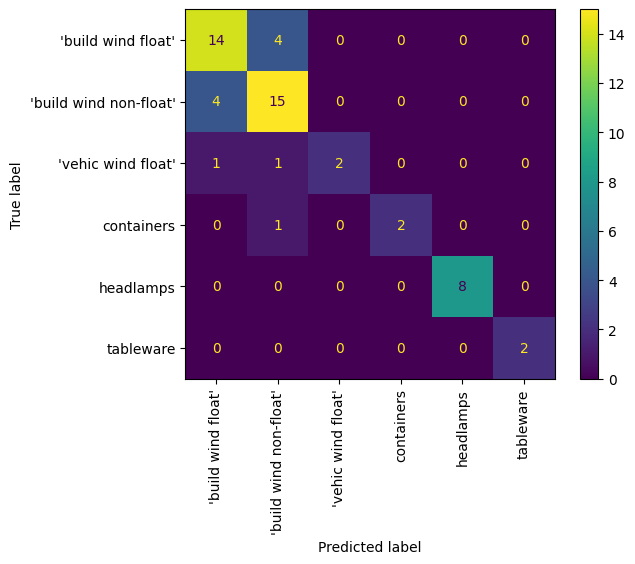

In [ ]:
cm = confusion_matrix(y_test, pred)
cm_display = ConfusionMatrixDisplay(cm, display_labels = knn.classes_)
cm_display.plot()

plt.xticks(rotation=90)
plt.show()

Ahora que tenemos nuestro modelo calibrado, vamos a predecir sobre la observación nueva que nos brinda el enunciado.

Armamos un dataframe con la fila nueva:

In [ ]:
new_data = pd.DataFrame({"RI":[1.429], "Na": [15.15], "Mg" : [0.1], "Al": [2.15], "Si": [72.94], "K": [0], "Ca": [10.78], "Ba":[0], "Fe": [0]})

In [ ]:
new_data

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.429,15.15,0.1,2.15,72.94,0,10.78,0,0


In [ ]:
columns_x = new_data.columns

Debemos estandarizarla de la misma manera que hicimos con nuestro dataset original.

In [ ]:
new_data_scaled = scaler.transform(new_data)

Solicitamos a nuestro modelo la predicción correspondiente:

In [ ]:
prediccion = knn.predict(new_data_scaled)[0]

In [ ]:
prediccion

'tableware'

Creamos una columna con la predicción.

In [ ]:
new_data["Type"] = prediccion

In [ ]:
new_data

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.429,15.15,0.1,2.15,72.94,0,10.78,0,0,tableware


Ahora lo que buscaremos es graficar este vidrio nuevo, con nuestro conjunto de datos de entrenamiento original.
Para eso primero, aplicamos la inversa de el Scaler para obtener los valores originales. Luego creamos un dataframe, ya que el scaler nos devuelve una matriz. Y finalmente, juntamos las X con la y en un solo dataset.

In [ ]:
X_train_original = scaler.inverse_transform(X_train)
X_train_original = pd.DataFrame(data= X_train_original,columns = columns_x )
X_train_original["Type"] = y

Unimos los datos de entrenamiento con la observación nueva..

In [ ]:
X_train_original["dataset"] = "Original"
new_data["dataset"] = "Nueva"

data = pd.concat([X_train_original, new_data])

In [ ]:
import seaborn as sns

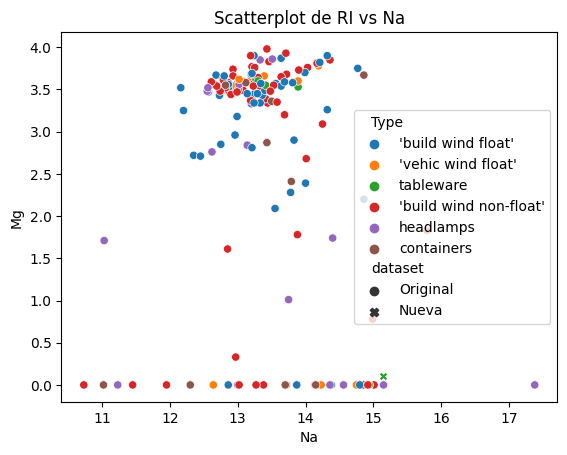

In [ ]:
sns.scatterplot(data = data, x = "Na", y = "Mg", hue = "Type", style = "dataset")
plt.title("Scatterplot de RI vs Na")
plt.show()

Links utiles:  
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

- https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html  